In [567]:
# Import necessary libraries for data manipulation, preprocessing, and visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd  
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold

# Configure seaborn style
sns.set_style("whitegrid", {"grid.color": ".6", "grid.linestyle": "--"})

## Part 1 – Data Inspection

In [568]:
# Load the dataset and inspect its dimensions and first few rows
Data = pd.read_csv("../data/Telco-Customer-Churn.csv")
print(Data.shape)
Data.head(10)

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [569]:
# Display detailed information about the dataset (data types, non-null counts, and memory usage)
print("Detailed information about the dataset:\n")
Data.info()

Detailed information about the dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  P

In [570]:
# Display the lists of categorical and numerical columns in the dataset
print(f'\nCategorical columns:\n\n{Data.select_dtypes(include="object").columns.to_list()}\n')
print('##' * 40)
print(f'\nNumerical columns:\n\n{Data.select_dtypes(include="number").columns.to_list()}')


Categorical columns:

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

################################################################################

Numerical columns:

['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [571]:
# Check the total number of duplicate rows in the dataset
duplic = Data.duplicated().sum()
print(f"The number of duplicate rows in the dataset is:\n{duplic}")

The number of duplicate rows in the dataset is:
0


In [572]:
# Check the number of missing values per feature
missing = Data.isnull().sum()
print(f"The number of missing values per feature are:\n{missing}")

The number of missing values per feature are:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [573]:
# Generate a statistical summary for the entire dataset and round the values to 2 decimal places
Data.describe(include='all').round(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.00,7043,7043,7043.00,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.00,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.16,NaN,NaN,32.37,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.76,NaN,NaN
std,NaN,NaN,0.37,NaN,NaN,24.56,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.09,NaN,NaN
min,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.25,NaN,NaN
25%,NaN,NaN,0.00,NaN,NaN,9.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.50,NaN,NaN
50%,NaN,NaN,0.00,NaN,NaN,29.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.35,NaN,NaN
75%,NaN,NaN,0.00,NaN,NaN,55.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.85,NaN,NaN


In [574]:
# Display statistical summary for numerical features
Data.describe(include="number")

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [575]:
# Display statistical summary for object (categorical) features
Data.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## Part 2 – Data Cleaning

 In this part, we check for duplicated rows and missing values. Since our dataset 
does not contain these issues, we will focus directly on data type correction and standardization.

Looking at the TotalCharges column, we notice that it contains numeric values 
but is defined with an object data type. This happens because for customers with a tenure of 0, 
TotalCharges is recorded as an empty string, causing pandas to interpret the entire column as text.

In [576]:
Data[Data['tenure'] == 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [577]:
Data["TotalCharges"] = pd.to_numeric(Data["TotalCharges"] , errors = "coerce")

In [578]:
Data["TotalCharges"].dtypes

dtype('float64')

 Churn is the target variable in the dataset, but since it has an object data type, 
 we need to convert it into a numerical data type.

In [579]:
Data.Churn = Data["Churn"].map({"No":0 , 'Yes':1})

In [580]:
Data["Churn"].dtypes

dtype('int64')

In [581]:
# Standardization of inconsistent values

## In this step, we verify that each value is homogeneous to ensure consistency.

In [582]:
col = Data.columns.to_list()

In [583]:
# Check unique values and their frequencies to detect inconsistencies or duplicated meanings for the same category
for val in col:
    print(Data[val].unique())
    print(Data[val].value_counts())


['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64
['Female' 'Male']
gender
Male      3555
Female    3488
Name: count, dtype: int64
[0 1]
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
['Yes' 'No']
Partner
No     3641
Yes    3402
Name: count, dtype: int64
['No' 'Yes']
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
['No' 'Yes']
Phon

## Part 3 – Feature Engineering

In [584]:
num_feat = Data.select_dtypes(include="number")
num_feat

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
0,0,1,29.85,29.85,0
1,0,34,56.95,1889.50,0
2,0,2,53.85,108.15,1
3,0,45,42.30,1840.75,0
4,0,2,70.70,151.65,1
...,...,...,...,...,...
7038,0,24,84.80,1990.50,0
7039,0,72,103.20,7362.90,0
7040,0,11,29.60,346.45,0
7041,1,4,74.40,306.60,1


In [585]:

num_feature = ['tenure', 'MonthlyCharges', 'TotalCharges']

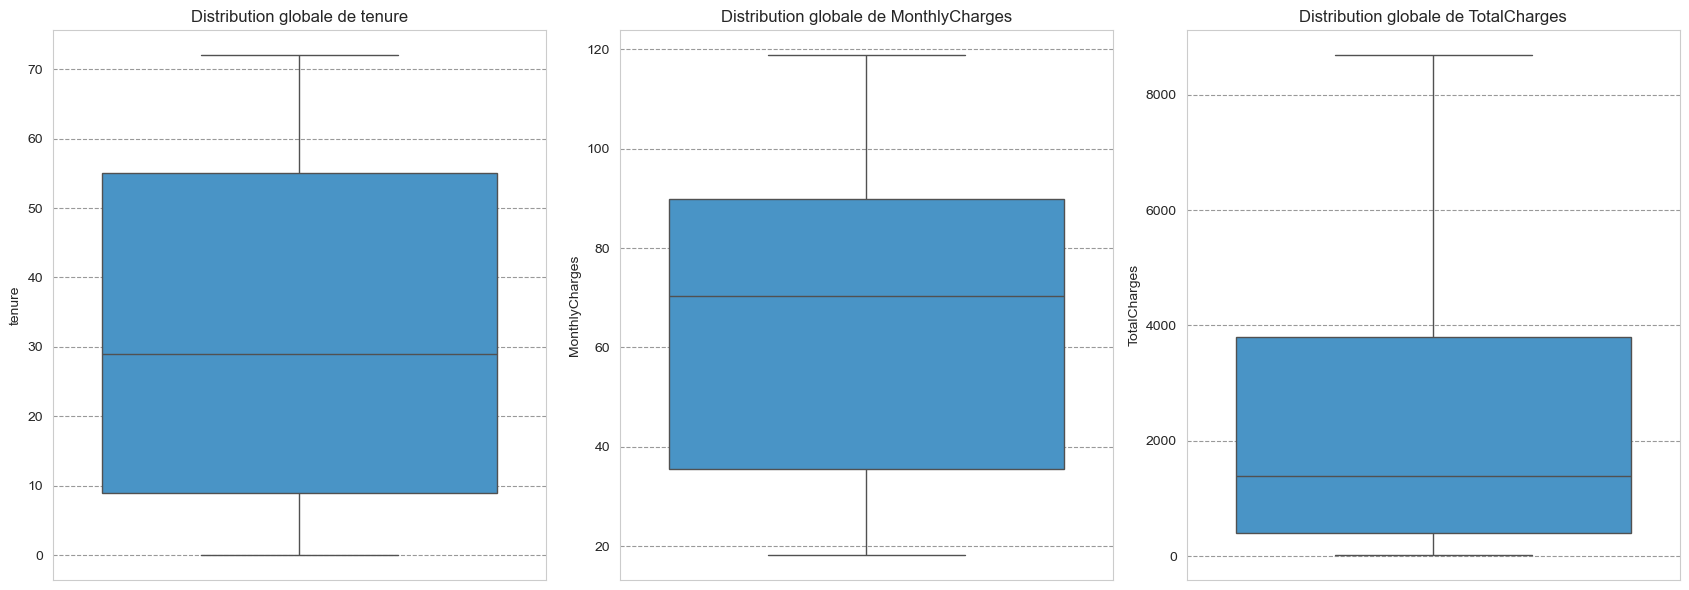

In [586]:
fig, ax = plt.subplots(1, 3, figsize=(17, 6))
ax = ax.flatten()


for i, col in enumerate(num_feature):
    
    sns.boxplot(
        data=Data, 
        y=col, 
        ax=ax[i], 
        color="#3498db" 
    )
    
    ax[i].set_title(f"Distribution globale de {col}")
    ax[i].set_ylabel(col)
fig.savefig("../image/boxplot_univariate.png")
plt.tight_layout()
plt.show()

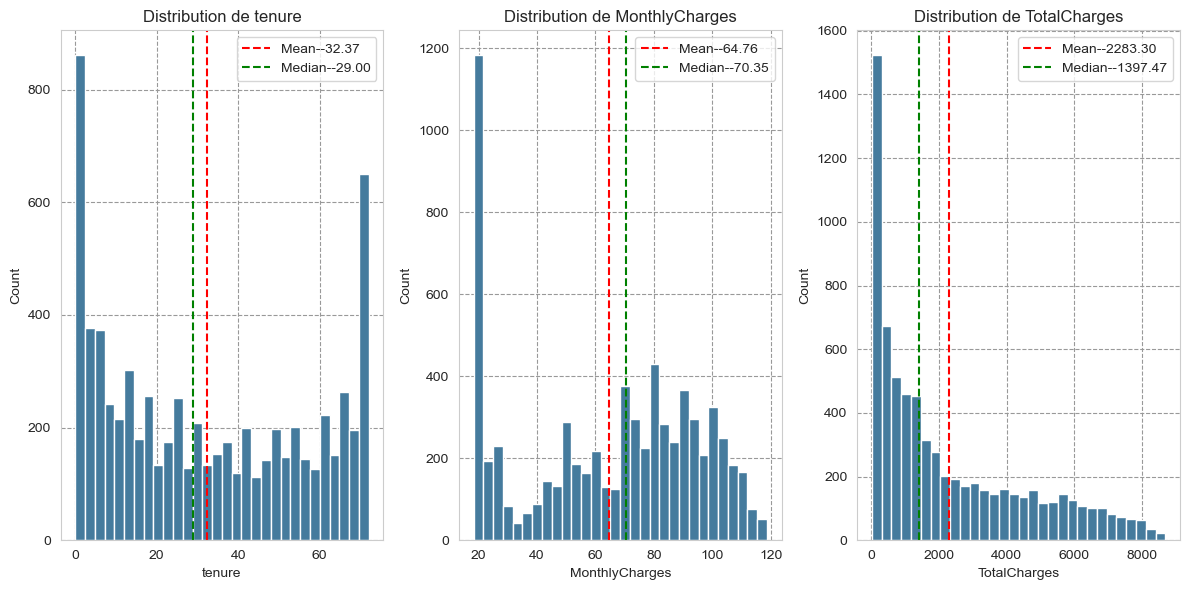

In [587]:
fig, ax = plt.subplots(1,3, figsize=(12,6))
ax = ax.flatten()

for i , val in enumerate(num_feature):
    ax[i].hist(Data[val].dropna() , bins=30, color="#457B9D" , edgecolor="white")
    ax[i].axvline(Data[val].mean(), linestyle="--" , color = "red", label = f"Mean--{Data[val].mean():.2f}")
    ax[i].axvline(Data[val].median(), linestyle="--", color="green", label= f"Median--{Data[val].median():.2f}")
    ax[i].set_title(f"Distribution de {val}")
    ax[i].set_xlabel(f"{val}")
    ax[i].set_ylabel("Count")
    ax[i].legend()

fig.savefig("../image/hisplot_univariate.png")
plt.tight_layout()
plt.show()

In [588]:
## Outliers handling with the IQR method
for col in num_feature:
    q_1 = Data[col].quantile(0.25)
    q_3 = Data[col].quantile(0.75)
    IQR = q_3 - q_1
    lowest_range = q_1 - 1.5 * IQR
    biggest_range = q_3 + 1.5 * IQR  # Corrected the plus sign
    
    # Clean filtering to keep only rows within the interquartile range
    Data = Data[(Data[col] >= lowest_range) & (Data[col] <= biggest_range)]

In [589]:
Data.shape



(7032, 21)

## Outlier Treatment Summary (IQR Method)

Applying the IQR method on `tenure`, `MonthlyCharges`, and `TotalCharges` removed 11 rows 
(7,043 → 7,032), confirming the box plots: no significant outliers. These 11 rows are the 
same `tenure == 0` customers with missing `TotalCharges` from Part 2 — NaN values fail the 
IQR bounds check, so this step also resolved that missing-value issue.

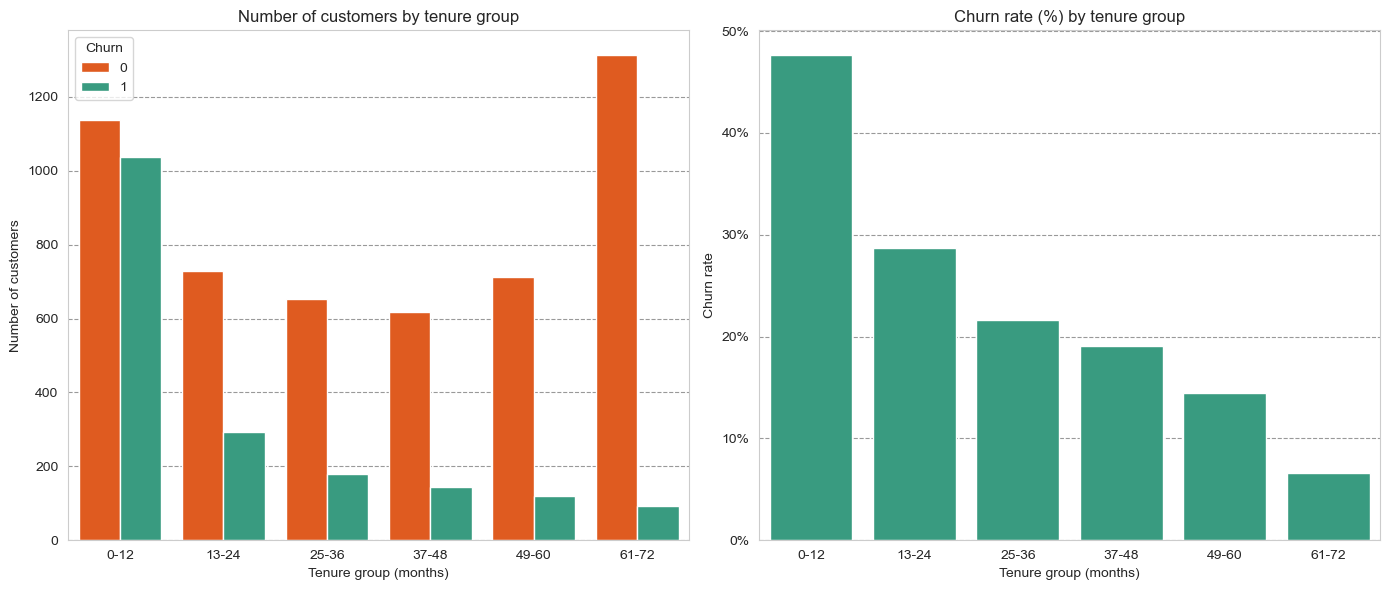

In [590]:
# Create tenure intervals
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
Data["tenure_group"] = pd.cut(Data["tenure"], bins=bins, labels=labels, include_lowest=True)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Number of customers per tenure group
sns.countplot(data=Data, x="tenure_group", hue="Churn", palette=["#FF4F00", "#29AB87"], ax=ax[0])
ax[0].set_title("Number of customers by tenure group")
ax[0].set_xlabel("Tenure group (months)")
ax[0].set_ylabel("Number of customers")

# Plot 2: Churn rate (%) per tenure group
churn_rate = Data.groupby("tenure_group", observed=True)["Churn"].mean().reset_index()
sns.barplot(data=churn_rate, x="tenure_group", y="Churn", color="#29AB87", ax=ax[1])
ax[1].set_title("Churn rate (%) by tenure group")
ax[1].set_xlabel("Tenure group (months)")
ax[1].set_ylabel("Churn rate")
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))

plt.tight_layout()
fig.savefig("../image/tenure_groups.png", dpi=300, bbox_inches="tight")
plt.show()

tenure_group: Transforms continuous tenure into 12-month intervals to help the model capture non-linearity and the gradual decrease in churn.

is_new_customer: Explicitly isolates the critical red zone (0-12 months, ~47% churn) via a binary indicator (1 or 0) to boost the detection of high-risk customers.

In [591]:
# 1. Create the tenure grouping feature
bins = [-1, 12, 24, 36, 48, 60, 72]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']

Data["tenure_group"] = pd.cut(Data['tenure'], bins=bins, labels=labels)

# 2. Create the binary indicator for the critical risk zone (first year)
Data["is_new_customer"] = (Data['tenure'] <= 12).astype(int)


Data["tenure_group"].head(10)

0     0-12
1    25-36
2     0-12
3    37-48
4     0-12
5     0-12
6    13-24
7     0-12
8    25-36
9    61-72
Name: tenure_group, dtype: category
Categories (6, object): ['0-12' < '13-24' < '25-36' < '37-48' < '49-60' < '61-72']

In [592]:
Data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,is_new_customer
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,0,25-36,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37-48,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12,1


In [593]:
corr = num_feat.corr()
mask = np.triu(np.ones_like(corr, dtype = bool))

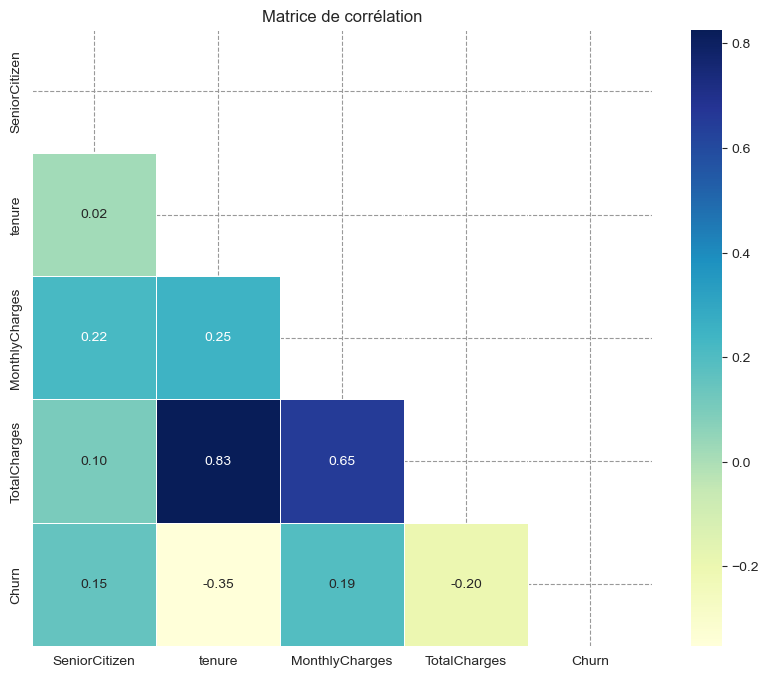

In [594]:

plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True,      
            fmt=".2f", 
            cmap="YlGnBu", 
            mask=mask,
            linewidths=0.5)
plt.title("Matrice de corrélation")
plt.show()

In [595]:
# Why the Chi-square test is chosen here: gender, PhoneService, and MultipleLines are categorical variables,
# so a correlation heatmap (which only covers numerical variables) cannot evaluate their relationship with Churn.
# The Chi-square test of independence is the appropriate test to verify whether a categorical feature is
# associated with another categorical feature (here, the target Churn) before deciding whether to drop them.

from scipy.stats import chi2_contingency

for col in ['gender', 'PhoneService', 'MultipleLines']:
    contingency = pd.crosstab(Data[col], Data['Churn'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col}: chi2={chi2:.2f}, p-value={p:.4f}")

gender: chi2=0.48, p-value=0.4905
PhoneService: chi2=0.87, p-value=0.3499
MultipleLines: chi2=11.27, p-value=0.0036


In [596]:

# Choosing Cramér's V here: the Chi-square test gave a significant p-value for MultipleLines,
# but with 7,043 rows, Chi-square alone doesn't show whether the effect is truly practical or 
# simply "significant" due to the large sample size. Cramér's V helps us decide whether 
# to keep or drop the variable.

def cramers_v(chi2, contingency_table):
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

contingency = pd.crosstab(Data['MultipleLines'], Data['Churn'])
v = cramers_v(11.27, contingency)
print(f"Cramér's V for MultipleLines: {v:.4f}")

Cramér's V for MultipleLines: 0.0400


Removal of TotalCharges: Eliminated to reduce multicollinearity and information redundancy 
with tenure and MonthlyCharges (see correlation heatmap, Part 3).

Removal of weak variables: Removed gender, PhoneService, and MultipleLines from the training set.

Justification: Chi-square tests against Churn confirm no significant association for gender 
(p=0.49) and PhoneService (p=0.35). MultipleLines shows a statistically significant association 
(p=0.0036), but Cramér's V = 0.04 indicates the effect size is negligible in practice. All three 
variables were therefore removed to reduce dimensionality without meaningful loss of predictive 
information.

In [597]:
# Liste des variables faibles à supprimer
variables_a_supprimer = ['gender', 'PhoneService', 'MultipleLines','customerID','TotalCharges']

# Suppression des variables si elles sont présentes dans le DataFrame
Data = Data.drop(columns=[col for col in variables_a_supprimer if col in Data.columns], errors='ignore')

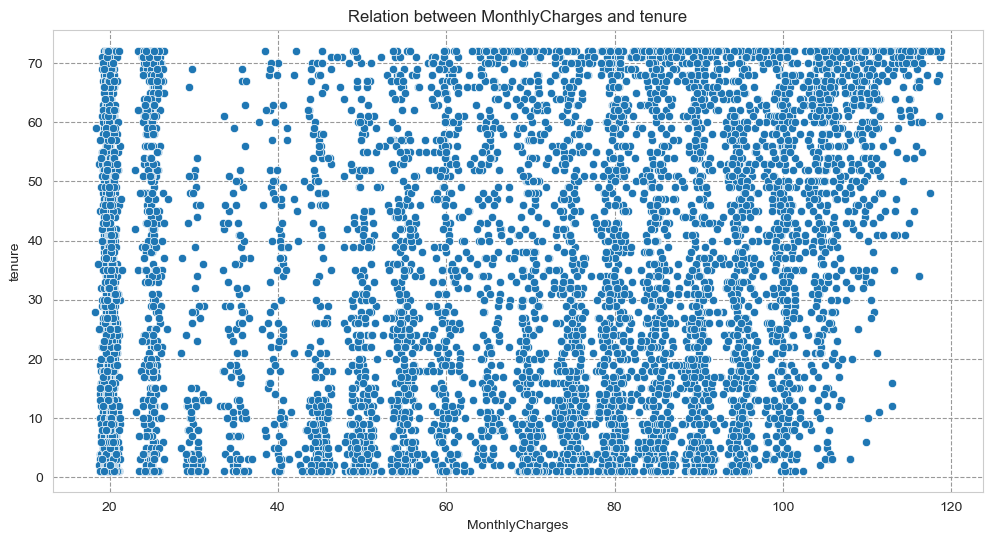

In [598]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(data=Data, x='MonthlyCharges', y='tenure')
plt.xlabel("MonthlyCharges")
plt.ylabel("tenure")
plt.title("Relation between MonthlyCharges and tenure")
plt.show()

Confirmed High Variance: The scatter plot shows a complete dispersion, proving the absence of collinearity between MonthlyCharges and tenure.

Feature Validation: Both variables are totally independent and complementary, which fully justifies keeping them both for modeling.

## Part 4 – Feature Encoding & Scaling

In [599]:
Data.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'Churn', 'tenure_group',
       'is_new_customer'],
      dtype='object')

For encoding categorical features: Using OneHotEncoder is an effective choice for handling categorical variables cleanly.

For numerical features: Using StandardScaler is well-suited here since you have no major outliers that would distort the scaling process.

In [600]:
# Define different transformers
standard = StandardScaler()
one_hot = OneHotEncoder(handle_unknown='ignore')
ordinal = OrdinalEncoder()

# Define features to be transformed
categorical_feature = Data.select_dtypes(include="object").columns.to_list()
numerical = ["tenure", "MonthlyCharges"]
ordinal_group = ["tenure_group"]

# Apply transformation
transformer = ColumnTransformer([
    ("Standardscaler", standard, numerical),
    ("oneHot", one_hot, categorical_feature),
    ("ordinal", ordinal, ordinal_group)
], remainder='passthrough')

transformed_array = transformer.fit_transform(Data)

# Automatically retrieve the generated feature names
raw_feature_names = transformer.get_feature_names_out()

# (Optional) Clean these names to remove technical prefixes like "oneHot__" or "Standardscaler__" if desired
clean_feature_names = [name.split("__")[-1] for name in raw_feature_names]

# Convert the array into a clean DataFrame with readable names
transformed_data = pd.DataFrame(transformed_array, columns=clean_feature_names, index=Data.index)

print(transformed_data.sample(10))


        tenure  MonthlyCharges  Partner_No  Partner_Yes  Dependents_No  \
3276 -1.158016        0.477060         1.0          0.0            1.0   
5182 -0.832064       -1.324572         1.0          0.0            1.0   
5963 -0.424625        0.460440         0.0          1.0            0.0   
2488 -0.057929       -0.317387         1.0          0.0            1.0   
6178  0.879182       -1.524015         0.0          1.0            1.0   
2896 -0.791321       -1.490774         1.0          0.0            1.0   
1805  1.612573       -0.011575         0.0          1.0            0.0   
5705 -1.280248       -1.500746         1.0          0.0            1.0   
4321 -0.750577        0.516948         1.0          0.0            1.0   
917   1.612573        0.024990         1.0          0.0            1.0   

      Dependents_Yes  InternetService_DSL  InternetService_Fiber optic  \
3276             0.0                  0.0                          1.0   
5182             0.0                 

In [601]:

# Isolate only the columns resulting from One-Hot Encoding (binary, unscaled features)
ohe_columns = [col for col in transformed_data.columns 
               if col not in ["tenure", "MonthlyCharges", "Churn", "tenure_group"]]

X_ohe = transformed_data[ohe_columns]

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_ohe)

kept_columns = X_ohe.columns[selector.get_support()]
removed_columns = X_ohe.columns[~selector.get_support()]

print(f"Columns removed due to low variance: {list(removed_columns)}")

Columns removed due to low variance: []


Variance Threshold (threshold = 0.01): No columns were dropped. All encoded variables show sufficient variance, confirming that no category is excessively rare or lacks discriminatory information—including is_new_customer, whose distribution (~30% of high-risk customers) remains well above the cutoff threshold

In [604]:
print(transformed_data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 40 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   tenure                                   7032 non-null   float64
 1   MonthlyCharges                           7032 non-null   float64
 2   Partner_No                               7032 non-null   float64
 3   Partner_Yes                              7032 non-null   float64
 4   Dependents_No                            7032 non-null   float64
 5   Dependents_Yes                           7032 non-null   float64
 6   InternetService_DSL                      7032 non-null   float64
 7   InternetService_Fiber optic              7032 non-null   float64
 8   InternetService_No                       7032 non-null   float64
 9   OnlineSecurity_No                        7032 non-null   float64
 10  OnlineSecurity_No internet service       7032 non-nul

## Part 6 – Machine Learning Ready Dataset

## To save the  processed dataset we use to_csv method

In [607]:
transformed_data.to_csv("../data/Telco-Customer-processed-Churn.csv", index=False)